In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("fraud_detection_dashboard_data.csv")



In [3]:
pca_columns = [f"V{i}" for i in range(1,29)]

pca_df = df[pca_columns]

pca_df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
0,0.032432,0.845050,0.161690,-0.798504,0.695579,-0.565116,0.933765,-0.062716,-0.349653,-0.255274,...,0.349512,0.013430,-0.229609,-0.491374,0.001259,-0.400306,-0.451544,0.143434,0.246293,0.084199
1,1.205443,0.289451,0.741620,0.746450,-0.682445,-1.276868,0.136546,-0.284828,-0.106272,-0.092854,...,-0.327784,-0.043590,-0.208169,-0.589665,0.185183,0.933687,0.168355,0.058053,-0.025197,0.027646
2,-0.275684,1.112403,0.942716,-0.136235,0.427005,-0.504525,0.686810,-0.014106,-0.322820,-0.506743,...,0.226162,0.130043,-0.321393,-0.851229,-0.121964,-0.509255,-0.052742,0.124297,0.244629,0.089349
3,1.802716,-0.304729,-2.092921,0.191727,0.553230,-1.079475,0.755031,-0.537489,1.236229,-0.280493,...,0.192921,0.061476,0.078572,0.251564,-0.165849,-0.392507,0.277481,0.121611,-0.135312,-0.068539
4,-2.525869,2.202607,0.633063,0.584094,-0.668050,0.201383,0.207289,0.336436,0.751606,1.596623,...,1.228771,0.166092,-0.191501,-0.238654,-0.115595,-0.024809,-0.158276,-0.669323,-1.506852,-0.739474


In [4]:
pca_corr = df[pca_columns + ["Class"]].corr()["Class"].drop("Class")

pca_corr

,Class
V1,-0.110949
V2,0.101267
V3,-0.203281
V4,0.117778
V5,-0.119833
V6,-0.043721
V7,-0.198666
V8,0.047929
V9,-0.093823
V10,-0.211482


In [5]:
top_positive = pca_corr.sort_values(ascending=False).head(5)

print("Top Positive PCA Features")
print(top_positive)

Top Positive PCA Features
V11    0.137595
V4     0.117778
V2     0.101267
V19    0.051279
V8     0.047929
Name: Class, dtype: float64


In [6]:
top_negative = pca_corr.sort_values().head(5)

print("\nTop Negative PCA Features")
print(top_negative)


Top Negative PCA Features
V17   -0.337094
V14   -0.254896
V12   -0.246671
V10   -0.211482
V3    -0.203281
Name: Class, dtype: float64


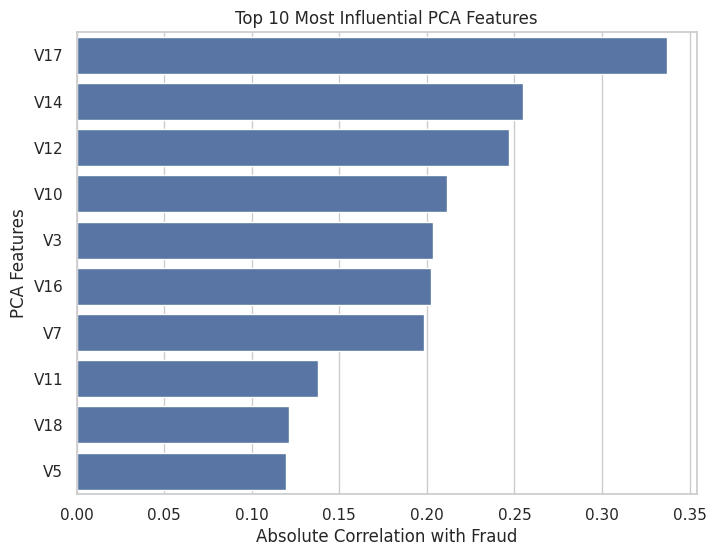

In [7]:
top_features = pca_corr.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title("Top 10 Most Influential PCA Features")
plt.xlabel("Absolute Correlation with Fraud")
plt.ylabel("PCA Features")

plt.show()